# **Worksheet 1 – Image Understanding and Compression with PCA**

**2.1 Exercise – 1**

Read, inspect, and modify a color image
What this part does

In this exercise, you will:

* load and display a color image,

* crop the top-left 100 x 100 region,

* separate and show the R, G, and B channels,

* modify the top-left 100 x 100 pixels to value 210,

* and display the updated image.

**Step 1: Import libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

**Step 2: Load and prepare the image**

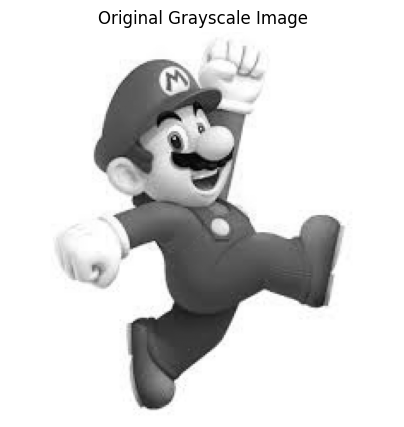

Image shape: (225, 225)


In [2]:
# Load image
img = Image.open("/content/drive/MyDrive/Artifical Intelligence and Machine Learning/Image.jpg")

# Convert to grayscale if it is a color image
gray_img = img.convert("L")

# Convert grayscale image to NumPy array
A = np.array(gray_img, dtype=np.float64)

# Display original grayscale image
plt.figure(figsize=(5, 5))
plt.imshow(A, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

# Print shape of image
print("Image shape:", A.shape)

**Step 3: Center / standardize the data**

What this does

For PCA, we subtract the mean from each column so the data becomes centered around zero.

In [3]:
# Compute mean of each column
mean_vec = np.mean(A, axis=0)

# Center the image data
A_centered = A - mean_vec

print("Centered data shape:", A_centered.shape)

Centered data shape: (225, 225)


**Step 4: Compute covariance matrix**

In [4]:
# Covariance matrix of centered data
cov_matrix = np.cov(A_centered, rowvar=False)

print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (225, 225)


**Step 5: Compute eigenvalues and eigenvectors**

In [5]:
# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)

Eigenvalues shape: (225,)
Eigenvectors shape: (225, 225)


**Step 6: Sort eigenvalues and eigenvectors in descending order**

In [6]:
# Sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]

# Reorder eigenvalues and eigenvectors
eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

**Step 7: Compute explained variance and cumulative explained variance**

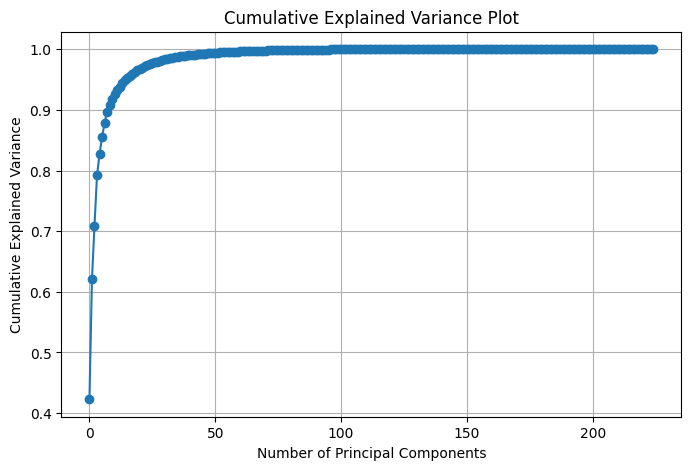

In [7]:
# Explained variance ratio
explained_variance_ratio = eigenvalues_sorted / np.sum(eigenvalues_sorted)

# Cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(cumulative_explained_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance Plot")
plt.grid(True)
plt.show()

**Step 8: PCA reconstruction function**

What this does

This function:

* selects the top k principal components,

* projects the image into lower dimensions,

* reconstructs it back,

* and returns the compressed version.

In [8]:
def reconstruct_image_pca(A_centered, mean_vec, eigenvectors_sorted, k):
    """
    Reconstruct image using top-k principal components.
    """

    # Select top-k eigenvectors
    W_k = eigenvectors_sorted[:, :k]

    # Project centered data onto k principal components
    Z_k = np.dot(A_centered, W_k)

    # Reconstruct the image from lower-dimensional representation
    A_reconstructed = np.dot(Z_k, W_k.T) + mean_vec

    return A_reconstructed

**Step 9: Reconstruct image with four different numbers of components**

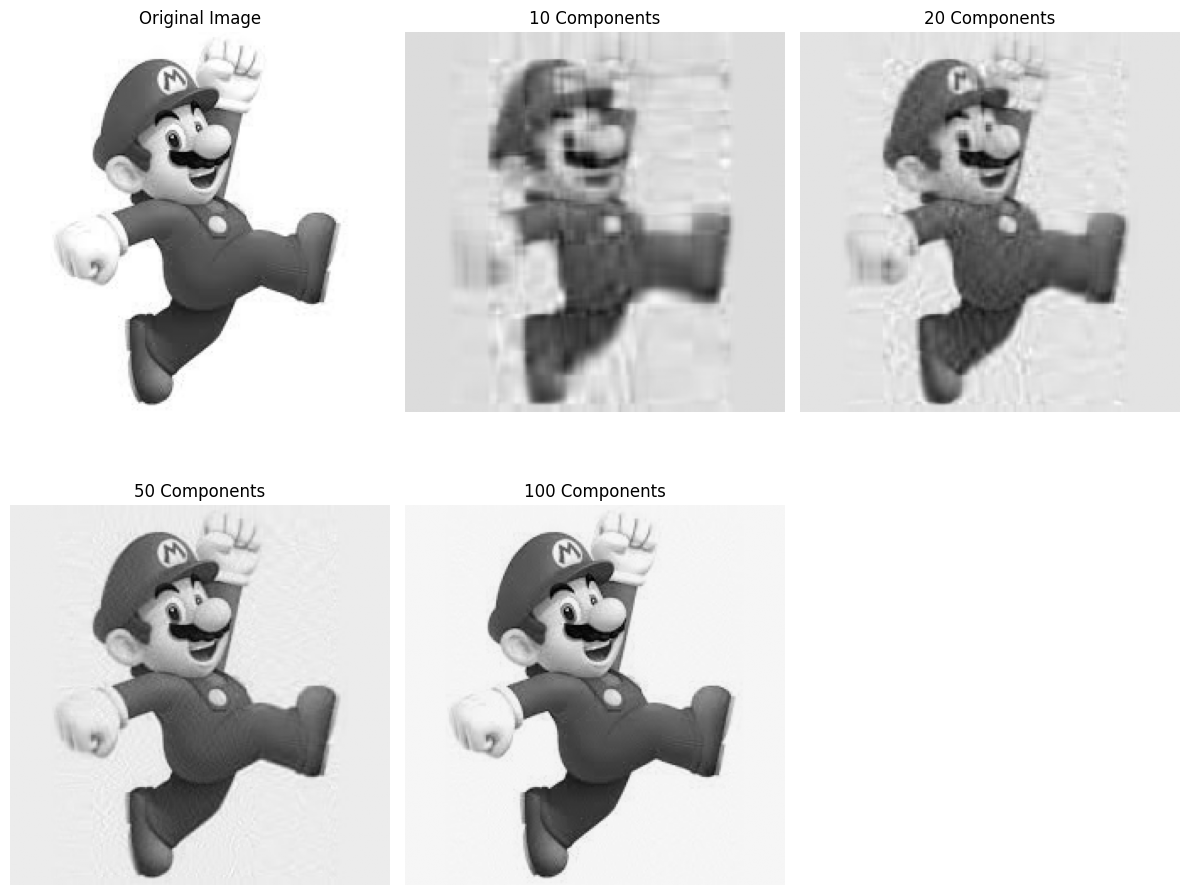

In [9]:
# Choose four different component counts
k_values = [10, 20, 50, 100]

# Create figure
plt.figure(figsize=(12, 10))

# Show original image first
plt.subplot(2, 3, 1)
plt.imshow(A, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Reconstruct and display images
for i, k in enumerate(k_values, start=2):
    reconstructed = reconstruct_image_pca(A_centered, mean_vec, eigenvectors_sorted, k)

    plt.subplot(2, 3, i)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"{k} Components")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Step 10: Use explained variance thresholds instead of fixed k**

What this does

This part chooses the number of components based on explained variance, which matches the worksheet requirement more closely.

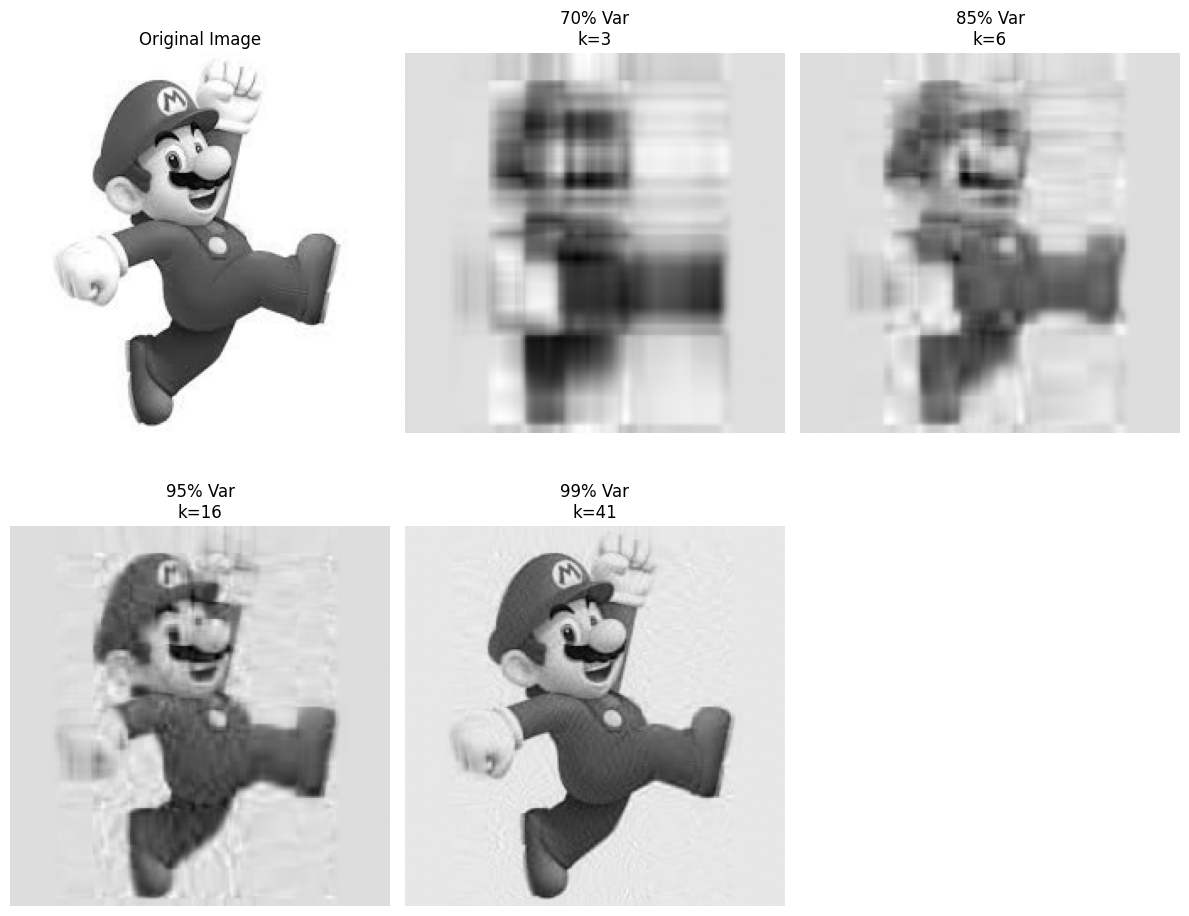

In [10]:
# Different explained variance targets
variance_targets = [0.70, 0.85, 0.95, 0.99]

plt.figure(figsize=(12, 10))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(A, cmap="gray")
plt.title("Original Image")
plt.axis("off")

for i, target in enumerate(variance_targets, start=2):
    # Find smallest k achieving the target variance
    k = np.argmax(cumulative_explained_variance >= target) + 1

    # Reconstruct image
    reconstructed = reconstruct_image_pca(A_centered, mean_vec, eigenvectors_sorted, k)

    plt.subplot(2, 3, i)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"{int(target*100)}% Var\nk={k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Step 11: Display component counts and explained variance**

In [11]:
for target in variance_targets:
    k = np.argmax(cumulative_explained_variance >= target) + 1
    print(f"To retain {int(target*100)}% variance, number of components needed = {k}")

To retain 70% variance, number of components needed = 3
To retain 85% variance, number of components needed = 6
To retain 95% variance, number of components needed = 16
To retain 99% variance, number of components needed = 41


**Full PCA block in one go**

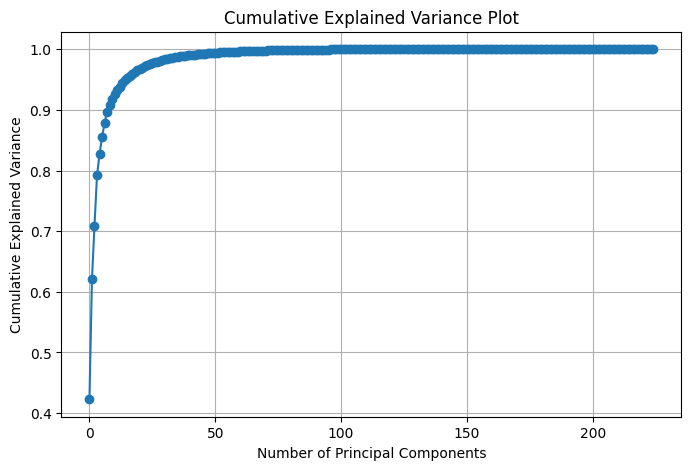

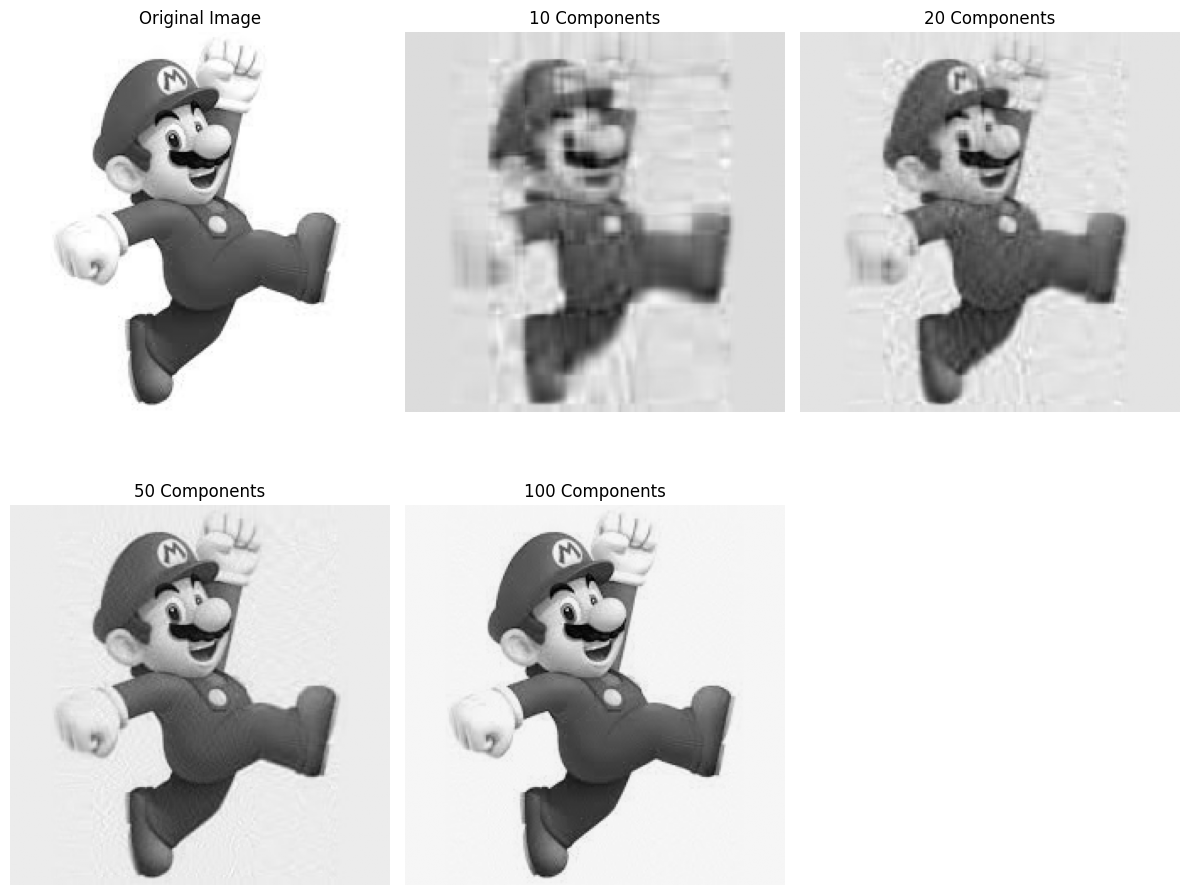

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image and convert to grayscale
img = Image.open("/content/drive/MyDrive/Artifical Intelligence and Machine Learning/Image.jpg")
gray_img = img.convert("L")
A = np.array(gray_img, dtype=np.float64)

# Center data
mean_vec = np.mean(A, axis=0)
A_centered = A - mean_vec

# Covariance matrix
cov_matrix = np.cov(A_centered, rowvar=False)

# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

# Explained variance
explained_variance_ratio = eigenvalues_sorted / np.sum(eigenvalues_sorted)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(cumulative_explained_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance Plot")
plt.grid(True)
plt.show()

# Reconstruction function
def reconstruct_image_pca(A_centered, mean_vec, eigenvectors_sorted, k):
    W_k = eigenvectors_sorted[:, :k]
    Z_k = np.dot(A_centered, W_k)
    A_reconstructed = np.dot(Z_k, W_k.T) + mean_vec
    return A_reconstructed

# Reconstruct with different component counts
k_values = [10, 20, 50, 100]

plt.figure(figsize=(12, 10))

plt.subplot(2, 3, 1)
plt.imshow(A, cmap="gray")
plt.title("Original Image")
plt.axis("off")

for i, k in enumerate(k_values, start=2):
    reconstructed = reconstruct_image_pca(A_centered, mean_vec, eigenvectors_sorted, k)
    plt.subplot(2, 3, i)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"{k} Components")
    plt.axis("off")

plt.tight_layout()
plt.show()